In [63]:
import pandas as pd

df = pd.read_excel("/content/dataset.xlsx")

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [90]:
df = df[df['status'].isin(['Normal', 'Depression', 'Suicidal'])]

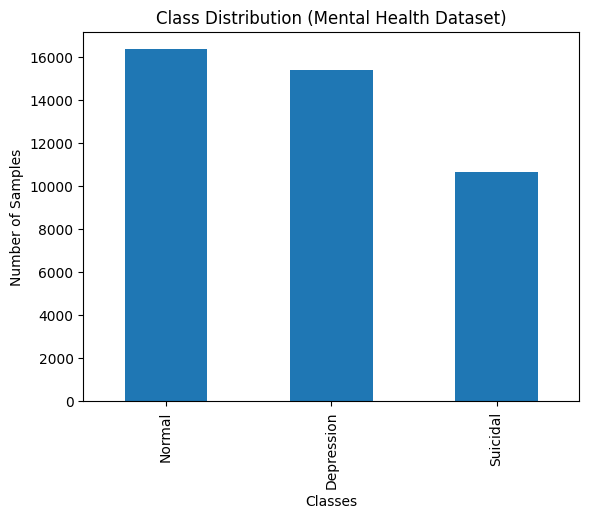

In [91]:
import matplotlib.pyplot as plt

df['status'].value_counts().plot(kind='bar')
plt.title("Class Distribution (Mental Health Dataset)")
plt.xlabel("Classes")
plt.ylabel("Number of Samples")
plt.show()

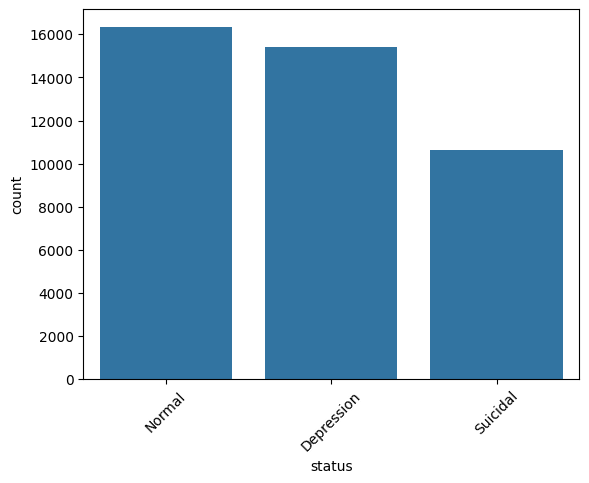

In [92]:
df['status'].value_counts()
df['status'].unique()
sns.countplot(x='status', data=df)
plt.xticks(rotation=45)
plt.show()

In [93]:
df = df.dropna(subset=['statement', 'status'])

In [94]:
df = df.drop_duplicates()

In [95]:
df = df.reset_index(drop=True)

In [96]:
import nltk
from nltk.corpus import stopwords
import re

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

important_words = {"no","not","nor","n't","never","none","nobody","nothing","nowhere","neither","hardly","scarcely","barely","doesn't","isn't","wasn't","shouldn't","wouldn't","couldn't","won't","can't","don't"}

stop_words = stop_words - important_words

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [97]:
def remove_stopwords(text):
    if not isinstance(text, str):
        return ""   # or return text, but empty is safer

    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)

    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [98]:
df['clean_statement'] = df['statement'].apply(remove_stopwords)

In [99]:
print(df[['statement', 'clean_statement']].head())

                                           statement  \
0      Gr gr dreaming of ex crush to be my game, God   
1                                 wkwkwk what a joke   
2  Leaves are also standby in front of the PC ......   
3     Thank God even though it's just a ride through   
4  wedding teaser concept using the song day6 - o...   

                                     clean_statement  
0                   gr gr dreaming ex crush game god  
1                                        wkwkwk joke  
2  leaves also standby front pc office no longer ...  
3                         thank god even though ride  
4  wedding teaser concept using song day6 sounds ...  


In [100]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['status'])

In [101]:
dict(zip(le.classes_, le.transform(le.classes_)))

{'Depression': np.int64(0), 'Normal': np.int64(1), 'Suicidal': np.int64(2)}

In [102]:
from sklearn.model_selection import train_test_split

X = df['clean_statement']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [103]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [104]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)

model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000)

In [105]:
y_pred = model.predict(X_test_tfidf)

In [106]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8191577208918249
              precision    recall  f1-score   support

           0       0.82      0.72      0.77      3079
           1       0.91      0.96      0.94      3268
           2       0.68      0.75      0.71      2130

    accuracy                           0.82      8477
   macro avg       0.80      0.81      0.80      8477
weighted avg       0.82      0.82      0.82      8477



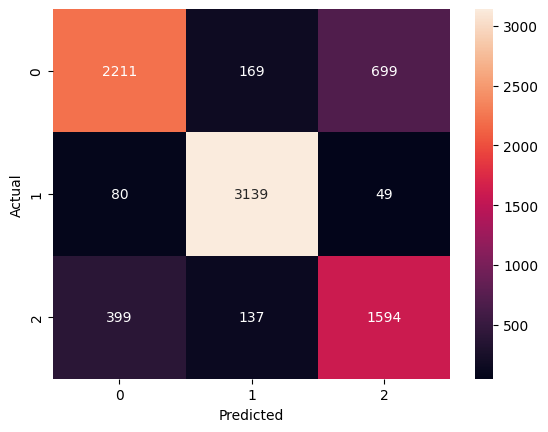

In [107]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [108]:
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [109]:
def predict_text(text):
    text = preprocess(text)
    text = remove_stopwords(text)
    vec = tfidf.transform([text])
    pred = model.predict(vec)
    return le.inverse_transform(pred)[0]

In [110]:
predict_text("i am enjoying nlp")

'Normal'

In [111]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(tfidf, "tfidf.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']